In [5]:
!pip install deepxde

In [ ]:
# import tensorflow as tf

# device_name = tf.test.gpu_device_name()
# if device_name != '/device:GPU:0':
#   print(
#       '\n\nThis error most likely means that this notebook is not '
#       'configured to use a GPU.  Change this in Notebook Settings via the '
#       'command palette (cmd/ctrl-shift-P) or the Edit menu.\n\n')
#   raise SystemError('GPU device not found')

In [ ]:
"""Backend supported: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle"""
import deepxde as dde
import matplotlib.pyplot as plt
import numpy as np
# Import tf if using backend tensorflow.compat.v1 or tensorflow
from deepxde.backend import tf
# Import torch if using backend pytorch
# import torch
# Import jax.numpy if using backend jax
# import jax.numpy as jnp
# Import paddle if using backend paddle
# import paddle


def pde(x, y):
    # Most backends
    dy_xx = dde.grad.hessian(y, x)
    # Backend jax
    # dy_xx, _ = dde.grad.hessian(y, x)
    # Use tf.sin for backend tensorflow.compat.v1 or tensorflow
    return -dy_xx - np.pi ** 2 * tf.sin(np.pi * x)
    # Use torch.sin for backend pytorch
    # return -dy_xx - np.pi ** 2 * torch.sin(np.pi * x)
    # Use jax.numpy.sin for backend jax
    # return -dy_xx - np.pi ** 2 * jnp.sin(np.pi * x)
    # Use paddle.sin for backend paddle
    # return -dy_xx - np.pi ** 2 * paddle.sin(np.pi * x)


def boundary(x, on_boundary):
    return on_boundary


def func(x):
    return np.sin(np.pi * x)


geom = dde.geometry.Interval(-1, 1)
bc = dde.icbc.DirichletBC(geom, func, boundary)
data = dde.data.PDE(geom, pde, bc, 16, 2, solution=func, num_test=100)

layer_size = [1] + [50] * 3 + [1]
activation = "tanh"
initializer = "Glorot uniform"
net = dde.nn.FNN(layer_size, activation, initializer)

model = dde.Model(data, net)
model.compile("adam", lr=0.001, metrics=["l2 relative error", "max APE"])

#losshistory, train_state = model.train(iterations=10000)
# Optional: Save the model during training.
checkpointer = dde.callbacks.ModelCheckpoint(
    "model/model", verbose=1, save_better_only=True )
# Optional: Save the movie of the network solution during training.
# ImageMagick (https://imagemagick.org/) is required to generate the movie.
movie = dde.callbacks.MovieDumper(
     "model/movie", [-1], [1], period=100, save_spectrum=True, y_reference=func
  )
losshistory, train_state = model.train(iterations=5000, callbacks=[checkpointer, movie])
#losshistory, train_state = model.train(iterations=5000, callbacks=[checkpointer])

dde.saveplot(losshistory, train_state, issave=True, isplot=True)

# Optional: Restore the saved model with the smallest training loss
model.restore(f"model/model-{train_state.best_step}.ckpt", verbose=1)
# Plot PDE residual
x = geom.uniform_points(1000, True)
y = model.predict(x, operator=pde)
plt.figure()
plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("PDE residual")
plt.show()

No backend selected.
Finding available backend...


In [23]:
"""Backend supported: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle"""
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt
from deepxde.backend import tf
import imageio.v2 as imageio
import matplotlib.ticker as mticker
from matplotlib import colors

#frequencies of solution
a = 1
b = 1
#domain boundaries
xmax = np.pi
ymax = np.pi
xmin = 0
ymin = 0
#number of iterations for training
N_iter = 5000
Nx_points = 100
Ny_points = 100

#precise solution
def u_precise(x):
  return np.sin(a*x[:, 0:1])*np.cos(b*x[:, 1:2])

#right hand side of Laplace equation
def f_right(x):
  return (a**2 + b**2)*tf.sin(a*x[:, 0:1])*tf.cos(b*x[:, 1:2])

def f_r(x):
  return (a**2 + b**2)*np.sin(a*x[:, 0:1])*np.cos(b*x[:, 1:2])

def g(x):
  return np.sin(a*x[:, 0:1])*np.cos(b*x[:, 1:2])

def pde(x, u):
    # Most backends
    du_xx = dde.grad.hessian(u, x, i=0, j=0)
    du_yy = dde.grad.hessian(u, x, i=1, j=1)
    # Backend jax
    # dy_xx, _ = dde.grad.hessian(y, x, i=0, j=0)
    # dy_yy, _ = dde.grad.hessian(y, x, i=1, j=1)
    f = (a**2 + b**2)*tf.sin(a*x[:, 0:1])*tf.cos(b*x[:, 1:2])
    return -du_xx - du_yy - f_right(x)

def boundary(_, on_boundary):
    return on_boundary

def save_movie(training_frames, N_frames, xmin, xmax, ymin, ymax, Nx_points, Ny_points, filename="movie.gif", fps=0.1):
    norm = colors.Normalize(vmin=np.min(training_frames), vmax=np.max(training_frames))
    with imageio.get_writer(filename, mode='I', fps=fps) as writer:
        for i in range(N_frames):
            fig = plt.figure(figsize=(4, 4))
            plt.imshow(training_frames[i:i+1, :].reshape(Nx_points, Ny_points, order = 'F'), extent=[xmin, xmax, ymin, ymax], cmap='jet', norm=norm)
            plt.title(f'Frame {i + 1}, iter {(i + 1) * 200}')
            plt.xlabel("x")
            plt.ylabel("y")
            plt.xticks(ticks = [0, np.pi/2, np.pi], labels = ['0', 'π/2', 'π'])
            #plt.xticklabels(['0', 'π/2', 'π'])
            plt.yticks(ticks = [0, np.pi/2, np.pi], labels = ['0', 'π/2', 'π'])
            #plt.yticklabels(['0', 'π/2', 'π'])
            # Save the plot to a temporary image
            plt.savefig('temp_plot.png', dpi=fig.dpi)
            writer.append_data(imageio.imread('temp_plot.png'))
            plt.close()  # Close the plot to avoid displaying it in interactive environments

    print(f"Movie saved as {filename}")

def predict_u_with_PINN(a, b, xmin, ymin, xmax, ymax, N_iter, Nx_points, Ny_points, call_save_movie = False, fps=0.1):
  geom = dde.geometry.Rectangle([0, 0], [xmax, ymax])
  #for zero boundary-conditions
  #bc = dde.icbc.DirichletBC(geom, lambda x: 0, boundary)
  bc = dde.icbc.DirichletBC(geom, g, boundary)
  data = dde.data.PDE(geom, pde, bc, num_domain=40**2, num_boundary=4*40, num_test=300, solution = u_precise)
  net = dde.nn.FNN([2] + [70] * 4 + [1], "tanh", "Glorot uniform")
  model = dde.Model(data, net)
  model.compile("adam", lr=0.001, metrics = ["l2 relative error"])
  #model.compile("adam", lr=0.001)
  # Optional: Save the model during training.
  checkpointer = dde.callbacks.ModelCheckpoint(
      "model/model", verbose=1, save_better_only=True )
  #model.compile("L-BFGS", metrics = ["l2 relative error"])
  #with tf.device('/device:GPU:0'):

  #Number of points for predicted solution
  x = geom.uniform_points(Nx_points*Ny_points, True)
  #alternative way of creating flat array of points for solution evaluation
  #X, Y = np.meshgrid(np.linspace(xmin, xmax, Nx_points), np.linspace(ymin, ymax, Ny_points))
  #x = np.vstack([X.ravel(order = 'F'), Y.ravel(order = 'F')]).T

  training_frames = np.empty((0, Nx_points*Ny_points))
  if call_save_movie:
      N_frames = N_iter // 200
      for i in range(N_frames):
          losshistory, train_state = model.train(iterations=100, callbacks=[checkpointer])
          U_pred = model.predict(x).T
          training_frames = np.concatenate((training_frames, U_pred), axis=0)
      losshistory, train_state = model.train(iterations=N_iter - N_frames * 200, callbacks=[checkpointer])
      file_name = "movie_" + str(a) + '_' + str(b) + ".gif"
      save_movie(training_frames, training_frames.shape[0], xmin, xmax, ymin, ymax, Nx_points, Ny_points, filename=file_name, fps=fps)
  else:
    losshistory, train_state = model.train(iterations=N_iter, callbacks=[checkpointer])
  dde.saveplot(losshistory, train_state, issave=True, isplot=True)
  # Optional: Restore the saved model with the smallest training loss
  model.restore(f"model/model-{train_state.best_step}.ckpt", verbose=1)

  #u - predicted solution, u_pr - precise solution

  #call model.predict(x, operator=pde) returns residual of the equation! not the solution itself
  u = model.predict(x).reshape(Nx_points, Ny_points, order='F')
  u_pr = u_precise(x).reshape(Nx_points, Ny_points, order='F')
  residual = model.predict(x, operator=pde).reshape(Nx_points, Ny_points, order='F')

  #eps_l2 = np.linalg.norm(u-u_pr)/np.linalg.norm(u_pr)
  eps_l2 = dde.metrics.l2_relative_error(u_pr, u)
  eps_c = np.max(u-u_pr)
  residual_l2 = np.linalg.norm(residual)/np.linalg.norm(f_r(x))
  residual_c = np.max(residual)

  print("eps_l2 = ", eps_l2)
  print("eps_c = ",eps_c)
  print("residual_l2 = ", residual_l2)
  print("residual_c = ", residual_c)

  return u, u_pr, training_frames

def plot_figures(u, u_pr, xmin, xmax, ymin, ymax, Nx_points, Ny_points):
    fig, axes = plt.subplots(2, 3, figsize=(10, 6), constrained_layout=True)

    # Set colormap
    cmap = 'jet'
    datasets = [u, u_pr, np.abs(u-u_pr)]
    norm = colors.Normalize(vmin=np.min(datasets), vmax=np.max(datasets))

    # Subplot a)
    im1 = axes[0, 0].imshow(u, extent=[xmin, xmax, ymin, ymax], cmap=cmap, norm=norm)
    axes[0, 0].set_title("a) predicted solution")
    axes[0, 0].set_xlabel("x")
    axes[0, 0].set_ylabel("y")
    axes[0, 0].set_xticks([0, np.pi/2, np.pi])
    axes[0, 0].set_xticklabels(['0', 'π/2', 'π'])
    axes[0, 0].set_yticks([0, np.pi/2, np.pi])
    axes[0, 0].set_yticklabels(['0', 'π/2', 'π'])

    # Subplot b)
    im2 = axes[0, 1].imshow(u_pr, extent=[xmin, xmax, ymin, ymax], cmap=cmap, norm=norm)
    axes[0, 1].set_title("b) precise solution")
    axes[0, 1].set_xticks([0, np.pi/2, np.pi])
    axes[0, 1].set_xticklabels(['0', 'π/2', 'π'])
    axes[0, 1].set_yticks([0, np.pi/2, np.pi])
    axes[0, 1].set_yticklabels(['0', 'π/2', 'π'])
    axes[0, 1].set_xlabel("x")
    axes[0, 1].set_ylabel("y")

    # Subplot c)
    im3 = axes[0, 2].imshow(np.abs(u_pr-u), extent=[xmin, xmax, ymin, ymax], cmap=cmap)
    axes[0, 2].set_title("c) difference")
    axes[0, 2].set_xticks([0, np.pi/2, np.pi])
    axes[0, 2].set_xticklabels(['0', 'π/2', 'π'])
    axes[0, 2].set_yticks([0, np.pi/2, np.pi])
    axes[0, 2].set_yticklabels(['0', 'π/2', 'π'])
    axes[0, 2].set_xlabel("x")
    axes[0, 2].set_ylabel("y")

    #colorbar for a), b)
    cbar1 = fig.colorbar(im2, ax=[axes[0, 0], axes[0, 1]],
                          pad=0.04, location='right', fraction = 0.022, ticks = mticker.LinearLocator(numticks = 5 ))
    #colorbar for c)
    cbar2 = fig.colorbar(im3, ax=[axes[0, 2]],
                          pad=0.04, location='right', fraction = 0.053, ticks = mticker.LinearLocator(numticks = 5 ))

    # Subplot d)
    y1 = np.linspace(ymin, ymax, Ny_points)
    #x = 0
    im4 = axes[1, 0].plot(y1, u[:, 0], '--', label = 'pred')
    axes[1, 0].plot(y1, u_pr[:, 0], label = 'true')
    axes[1, 0].legend(loc='upper right')
    axes[1, 0].set_title("d) x = x_min")
    axes[1, 0].set_xticks([0, np.pi/2, np.pi])
    axes[1, 0].set_xticklabels(['0', 'π/2', 'π'])
    axes[1, 0].set_xlabel("y")
    axes[1, 0].set_ylabel("u")

    # Subplot e)
    #x = pi/2
    im5 = axes[1, 1].plot(y1, u[:, Nx_points//2-1], '--', label = 'pred')
    axes[1, 1].plot(y1, u_pr[:, Nx_points//2-1], label = 'true')
    axes[1, 1].legend(loc='upper right')
    axes[1, 1].set_title("e) x = (x_min + x_max)/2")
    axes[1, 1].set_xticks([0, np.pi/2, np.pi])
    axes[1, 1].set_xticklabels(['0', 'π/2', 'π'])
    axes[1, 1].set_xlabel("y")
    axes[1, 1].set_ylabel("u")

    # Subplot f)
    #x = pi
    im6 = axes[1, 2].plot(y1, u[:, Nx_points-1], '--', label = 'pred')
    axes[1, 2].plot(y1, u_pr[:, Nx_points-1], label = 'true')
    axes[1, 2].legend(loc='upper right')
    axes[1, 2].set_title("f) x = x_max")
    axes[1, 2].set_xticks([0, np.pi/2, np.pi])
    axes[1, 2].set_xticklabels(['0', 'π/2', 'π'])
    axes[1, 2].set_xlabel("y")
    axes[1, 2].set_ylabel("u")

Compiling model...
Building feed-forward neural network...
'build' took 0.078430 s

'compile' took 0.966759 s

Training model...

Step      Train loss              Test loss               Test metric   
0         [1.10e+00, 4.09e-01]    [1.10e+00, 4.09e-01]    [1.25e+00]    
Epoch 1: train loss improved from inf to 1.51e+00, saving model to model/model-1.ckpt ...

100       [6.89e-02, 1.78e-02]    [6.10e-02, 1.78e-02]    [1.83e-01]    
Epoch 100: train loss improved from 1.51e+00 to 8.67e-02, saving model to model/model-100.ckpt ...


Best model at step 100:
  train loss: 8.67e-02
  test loss: 7.89e-02
  test metric: [1.83e-01]

'train' took 6.939964 s

Training model...

Step      Train loss              Test loss               Test metric   
100       [6.89e-02, 1.78e-02]    [6.10e-02, 1.78e-02]    [1.83e-01]    
200       [4.16e-03, 1.72e-03]    [2.50e-03, 1.72e-03]    [7.50e-02]    
Epoch 200: train loss improved from 8.67e-02 to 5.88e-03, saving model to model/model-200.ckpt ...



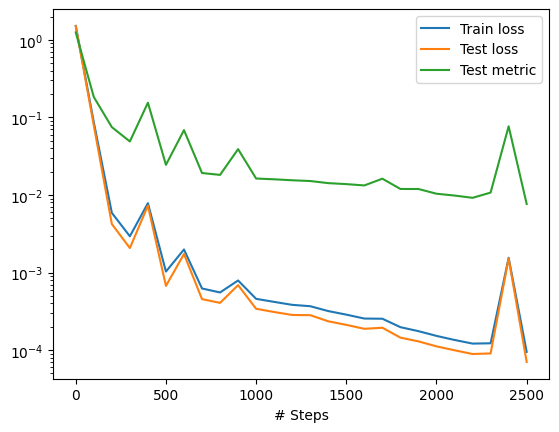

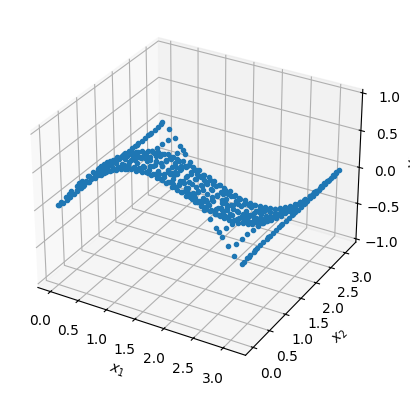

Restoring model from model/model-2500.ckpt ...

eps_l2 =  0.0056193983
eps_c =  0.018337006
residual_l2 =  0.0071082218
residual_c =  0.08872128


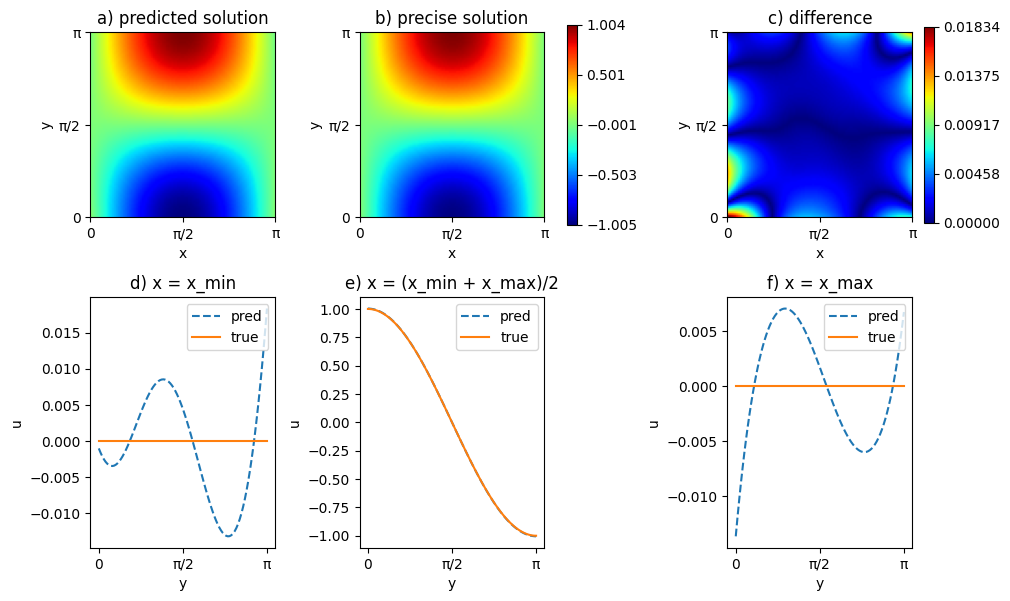

In [21]:
#frequencies of solution
a = 1
b = 1
#domain boundaries
xmax = np.pi
ymax = np.pi
xmin = 0
ymin = 0
#number of iterations for training
N_iter = 5000
Nx_points = 100
Ny_points = 100

u, u_pr, training_frames = predict_u_with_PINN(a, b, xmin, ymin, xmax, ymax, N_iter, Nx_points, Ny_points, call_save_movie=True, fps = 3)
# file_name = "movie_" + str(a) + '_' + str(b) + ".gif"
# save_movie(training_frames, training_frames.shape[0], xmin, xmax, ymin, ymax, Nx_points, Ny_points, filename=file_name, duration=0.6)

plot_figures(u, u_pr, xmin, xmax, ymin, ymax, Nx_points, Ny_points)

In [24]:
# file_name = "movie_" + str(a) + '_' + str(b) + ".gif"
# save_movie(training_frames, training_frames.shape[0], xmin, xmax, ymin, ymax, Nx_points, Ny_points, filename=file_name, fps = 3)

Movie saved as movie_1_1.gif


Compiling model...
Building feed-forward neural network...
'build' took 0.129060 s

'compile' took 1.233308 s

Training model...

Step      Train loss              Test loss               Test metric   
0         [2.10e+02, 2.67e-01]    [2.10e+02, 2.67e-01]    [1.05e+00]    
Epoch 1: train loss improved from inf to 2.11e+02, saving model to model/model-1.ckpt ...

100       [1.19e+02, 2.58e-01]    [1.17e+02, 2.58e-01]    [1.07e+00]    
Epoch 100: train loss improved from 2.11e+02 to 1.19e+02, saving model to model/model-100.ckpt ...


Best model at step 100:
  train loss: 1.19e+02
  test loss: 1.17e+02
  test metric: [1.07e+00]

'train' took 10.604034 s

Training model...

Step      Train loss              Test loss               Test metric   
100       [1.19e+02, 2.58e-01]    [1.17e+02, 2.58e-01]    [1.07e+00]    
200       [3.19e+01, 8.93e-01]    [1.80e+01, 8.93e-01]    [1.48e+00]    
Epoch 200: train loss improved from 1.19e+02 to 3.28e+01, saving model to model/model-200.ckpt ...


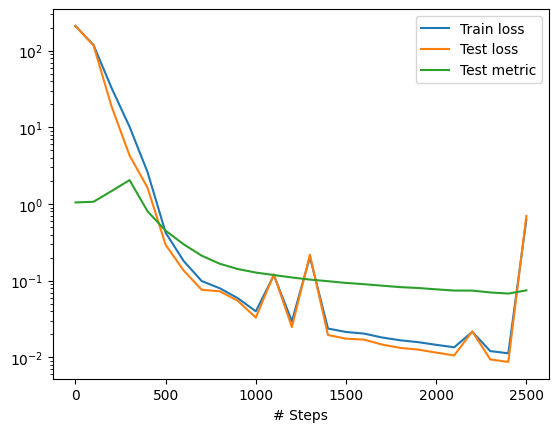

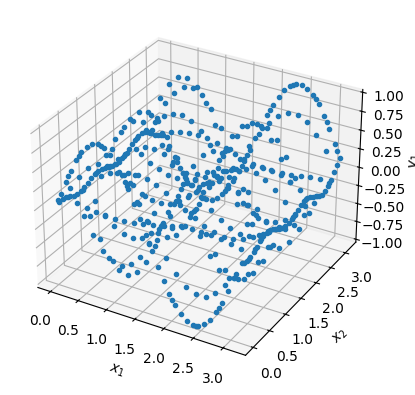

Restoring model from model/model-2400.ckpt ...

eps_l2 =  0.044085354
eps_c =  0.15908077
residual_l2 =  0.0060460805
residual_c =  0.8088024


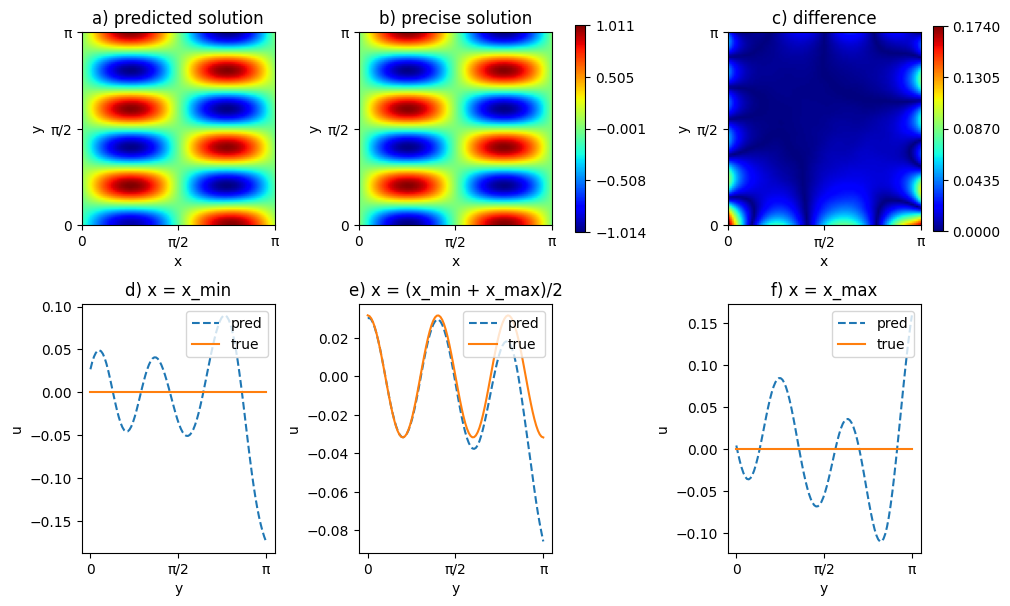

In [28]:
#frequencies of solution
a = 2
b = 5
#domain boundaries
xmax = np.pi
ymax = np.pi
xmin = 0
ymin = 0
#number of iterations for training
N_iter = 5000
Nx_points = 100
Ny_points = 100

u, u_pr, training_frames = predict_u_with_PINN(a, b, xmin, ymin, xmax, ymax, N_iter, Nx_points, Ny_points, call_save_movie=True, fps = 3)

plot_figures(u, u_pr, xmin, xmax, ymin, ymax, Nx_points, Ny_points)

Compiling model...
Building feed-forward neural network...
'build' took 0.100390 s

'compile' took 1.177136 s

Training model...

Step      Train loss              Test loss               Test metric   
0         [1.99e+03, 2.82e-01]    [1.97e+03, 2.82e-01]    [1.05e+00]    
Epoch 1: train loss improved from inf to 1.99e+03, saving model to model/model-1.ckpt ...

100       [1.51e+03, 2.64e+00]    [1.50e+03, 2.64e+00]    [3.13e+00]    
Epoch 100: train loss improved from 1.99e+03 to 1.52e+03, saving model to model/model-100.ckpt ...


Best model at step 100:
  train loss: 1.52e+03
  test loss: 1.50e+03
  test metric: [3.13e+00]

'train' took 7.029488 s

Training model...

Step      Train loss              Test loss               Test metric   
100       [1.51e+03, 2.64e+00]    [1.50e+03, 2.64e+00]    [3.13e+00]    
200       [1.04e+03, 8.31e-01]    [1.03e+03, 8.31e-01]    [2.27e+00]    
Epoch 200: train loss improved from 1.52e+03 to 1.04e+03, saving model to model/model-200.ckpt ...



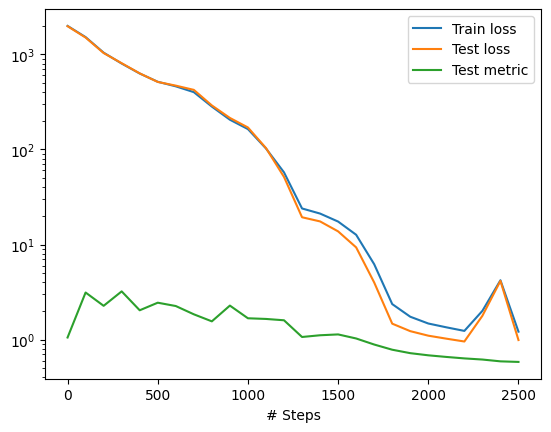

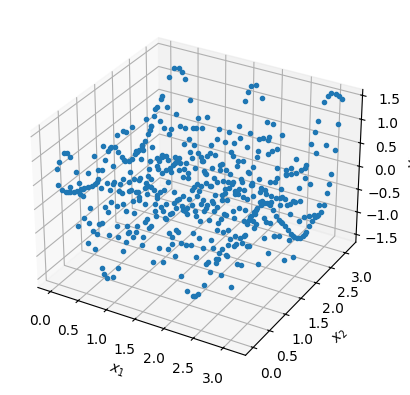

Restoring model from model/model-2500.ckpt ...

eps_l2 =  0.40249833
eps_c =  1.4692969
residual_l2 =  0.022527898
residual_c =  12.537633


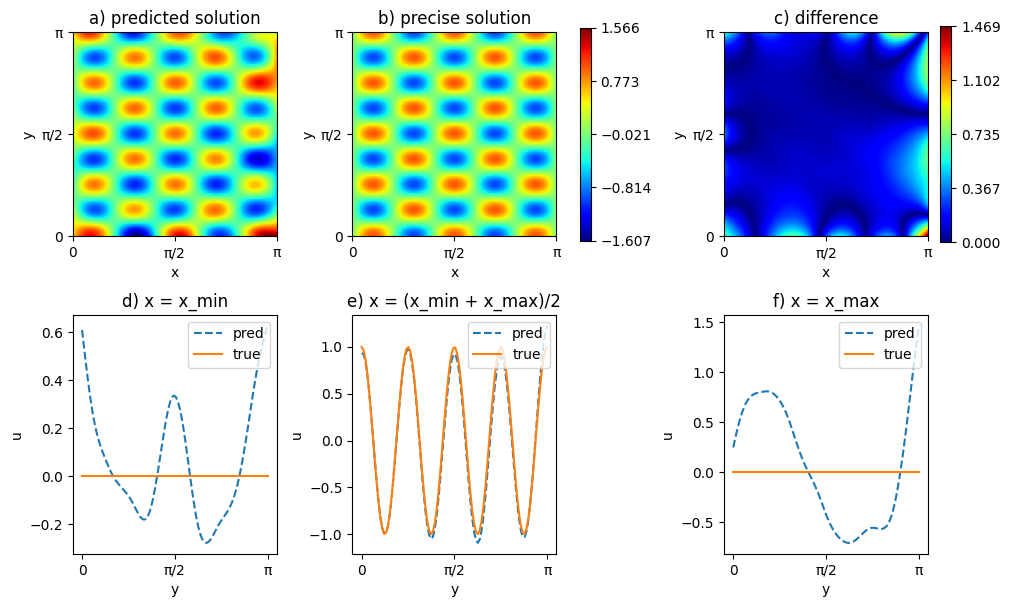

In [25]:
#frequencies of solution
a = 5
b = 8
#domain boundaries
xmax = np.pi
ymax = np.pi
xmin = 0
ymin = 0
#number of iterations for training
N_iter = 5000
Nx_points = 100
Ny_points = 100

u, u_pr, training_frames = predict_u_with_PINN(a, b, xmin, ymin, xmax, ymax, N_iter, Nx_points, Ny_points, call_save_movie=True, fps = 3)

plot_figures(u, u_pr, xmin, xmax, ymin, ymax, Nx_points, Ny_points)

Compiling model...
Building feed-forward neural network...
'build' took 0.148302 s

'compile' took 1.039741 s

Training model...

Step      Train loss              Test loss               Test metric   
0         [4.06e+03, 2.62e-01]    [4.08e+03, 2.62e-01]    [1.06e+00]    
Epoch 1: train loss improved from inf to 4.06e+03, saving model to model/model-1.ckpt ...

100       [3.23e+03, 6.20e-01]    [3.21e+03, 6.20e-01]    [1.87e+00]    
Epoch 100: train loss improved from 4.06e+03 to 3.23e+03, saving model to model/model-100.ckpt ...


Best model at step 100:
  train loss: 3.23e+03
  test loss: 3.21e+03
  test metric: [1.87e+00]

'train' took 9.077726 s

Training model...

Step      Train loss              Test loss               Test metric   
100       [3.23e+03, 6.20e-01]    [3.21e+03, 6.20e-01]    [1.87e+00]    
200       [2.80e+03, 8.66e+00]    [2.85e+03, 8.66e+00]    [5.42e+00]    
Epoch 200: train loss improved from 3.23e+03 to 2.81e+03, saving model to model/model-200.ckpt ...



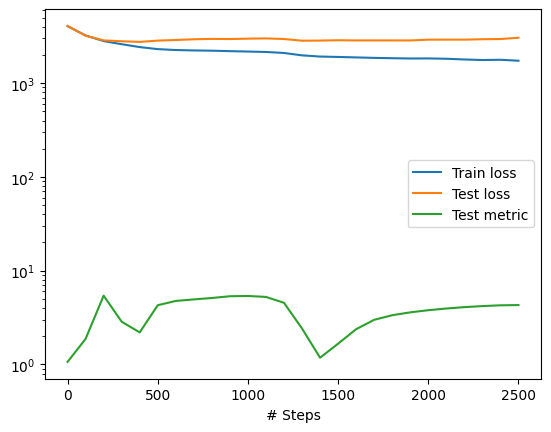

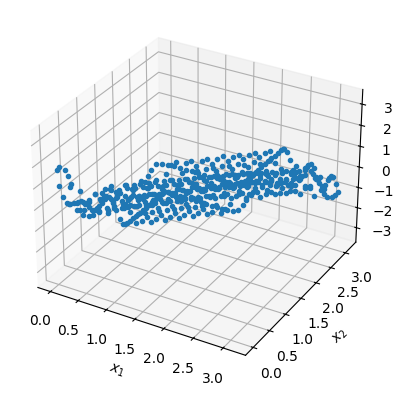

Restoring model from model/model-2500.ckpt ...

eps_l2 =  3.857424
eps_c =  4.535399
residual_l2 =  0.85082895
residual_c =  235.1297


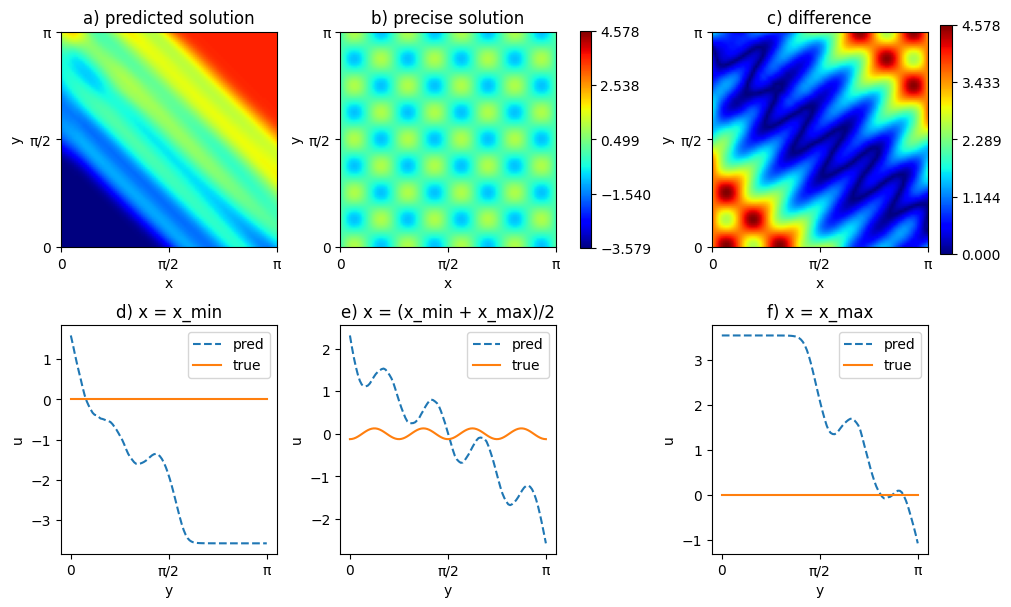

In [26]:
#frequencies of solution
a = 8
b = 8
#domain boundaries
xmax = np.pi
ymax = np.pi
xmin = 0
ymin = 0
#number of iterations for training
N_iter = 5000
Nx_points = 100
Ny_points = 100

u, u_pr, training_frames = predict_u_with_PINN(a, b, xmin, ymin, xmax, ymax, N_iter, Nx_points, Ny_points, call_save_movie=True, fps = 3)

plot_figures(u, u_pr, xmin, xmax, ymin, ymax, Nx_points, Ny_points)

Compiling model...
Building feed-forward neural network...
'build' took 0.075580 s

'compile' took 1.114966 s

Training model...

Step      Train loss              Test loss               Test metric   
0         [5.07e+04, 2.74e-01]    [5.05e+04, 2.74e-01]    [1.05e+00]    
Epoch 1: train loss improved from inf to 5.07e+04, saving model to model/model-1.ckpt ...

100       [5.00e+04, 7.03e-01]    [5.03e+04, 7.03e-01]    [1.43e+00]    
Epoch 100: train loss improved from 5.07e+04 to 5.00e+04, saving model to model/model-100.ckpt ...


Best model at step 100:
  train loss: 5.00e+04
  test loss: 5.03e+04
  test metric: [1.43e+00]

'train' took 12.535591 s

Training model...

Step      Train loss              Test loss               Test metric   
100       [5.00e+04, 7.03e-01]    [5.03e+04, 7.03e-01]    [1.43e+00]    
200       [4.41e+04, 8.41e-01]    [4.52e+04, 8.41e-01]    [1.86e+00]    
Epoch 200: train loss improved from 5.00e+04 to 4.41e+04, saving model to model/model-200.ckpt ...


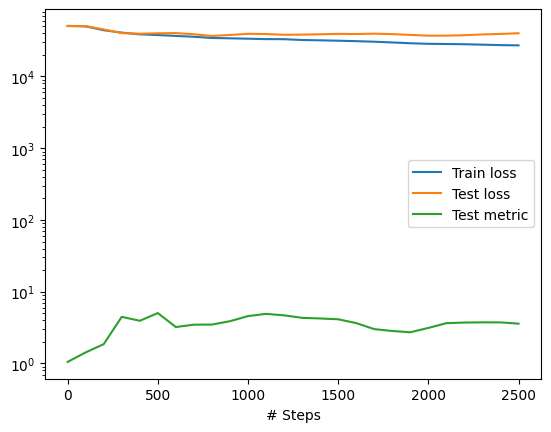

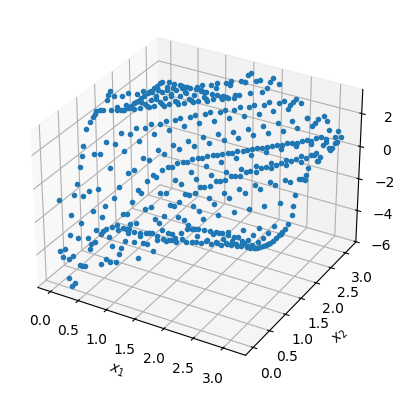

Restoring model from model/model-2500.ckpt ...

eps_l2 =  3.4498587
eps_c =  3.2705286
residual_l2 =  1.0566943
residual_c =  3770.949


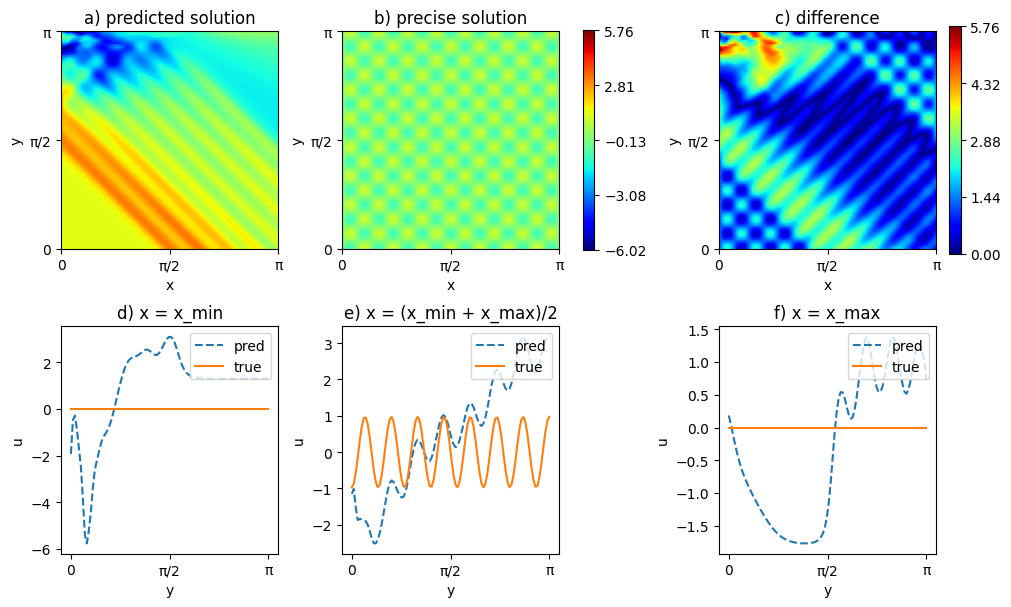

In [27]:
#frequencies of solution
a = 15
b = 15
#domain boundaries
xmax = np.pi
ymax = np.pi
xmin = 0
ymin = 0
#number of iterations for training
N_iter = 5000
Nx_points = 100
Ny_points = 100

u, u_pr, training_frames = predict_u_with_PINN(a, b, xmin, ymin, xmax, ymax, N_iter, Nx_points, Ny_points, call_save_movie=True, fps = 3)

plot_figures(u, u_pr, xmin, xmax, ymin, ymax, Nx_points, Ny_points)